In [1]:
import numpy as np
import glob
import os
import shutil
import re
from scipy.interpolate import griddata
from scipy.spatial import cKDTree
from netCDF4 import Dataset, num2date, date2num
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import time
import datetime
from concurrent.futures import ProcessPoolExecutor

# 查看原始数据

In [2]:
nc_file = "../../Getea/sst_forecast/sst_changjiang_2023010108.nc"
ds = Dataset(nc_file, mode='r')
print(ds.variables.keys())

sst_var = ds.variables['sst']
lon = ds.variables['lon'][:]
lat = ds.variables['lat'][:]

# 选取第 0 个时刻
sst = sst_var[0]

# 如果还有 siglay 维度，取表层（通常是 0）
if sst.ndim > 1:
    sst = sst[0, :]

sst = np.squeeze(sst)

time_var = ds.variables['time']
time_date = num2date(time_var[0], time_var.units)
time_str = time_date.strftime('%Y-%m-%d %H:%M')

dict_keys(['h', 'lat', 'lon', 'siglay', 'sst', 'time', 'zeta'])


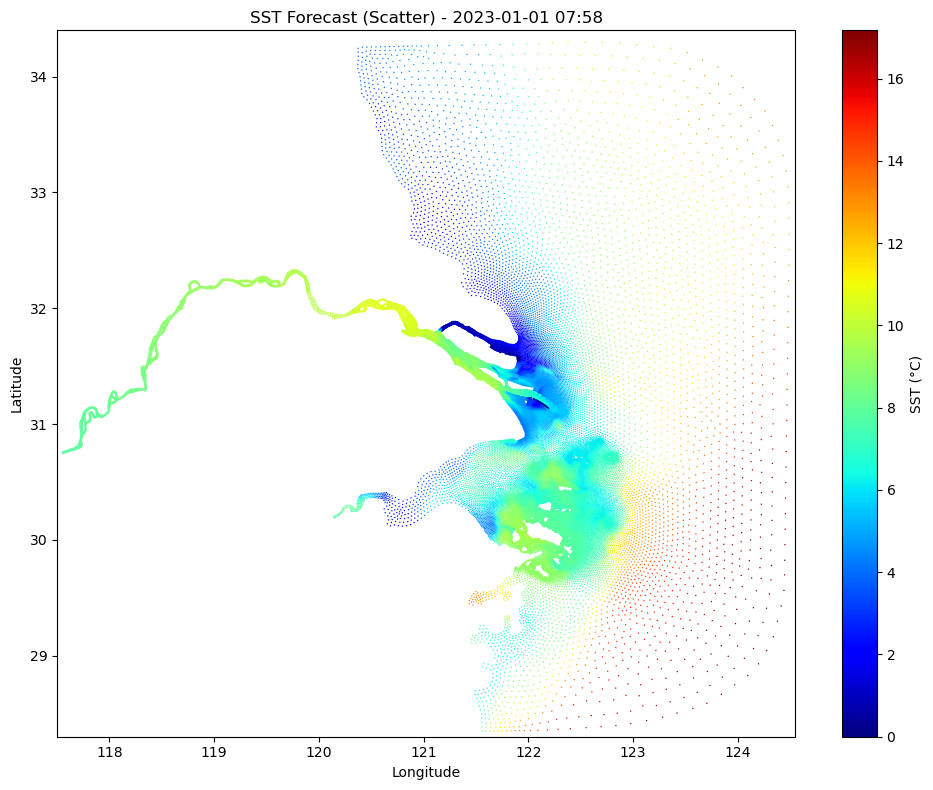

In [3]:
plt.figure(figsize=(10, 8))

plt.scatter(
    lon,
    lat,
    c=sst,
    s=1,
    cmap='jet',
    edgecolor='none'
)

lon_min, lon_max = 117.50, 124.55
lat_min, lat_max = 28.30, 34.40
plt.xlim(lon_min, lon_max)
plt.ylim(lat_min, lat_max)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(label='SST (°C)')
plt.title(f"SST Forecast (Scatter) - {time_str}")
plt.tight_layout()
plt.show()

ds.close()

In [4]:
nc_file = "../../Getea/sst_reanalysis/sst_Re_2023010108.nc"
ds = Dataset(nc_file, mode='r')
print(ds.variables.keys())

sst_var = ds.variables['sst']
lon = ds.variables['lon'][:]
lat = ds.variables['lat'][:]

# 选取第 0 个时刻
sst = sst_var[0]

# 如果还有 siglay 维度，取表层（通常是 0）
if sst.ndim > 1:
    sst = sst[0, :]

sst = np.squeeze(sst)

time_var = ds.variables['time']
time_date = num2date(time_var[0], time_var.units)
time_str = time_date.strftime('%Y-%m-%d %H:%M')

dict_keys(['h', 'lat', 'lon', 'siglay', 'sst', 'time', 'zeta'])


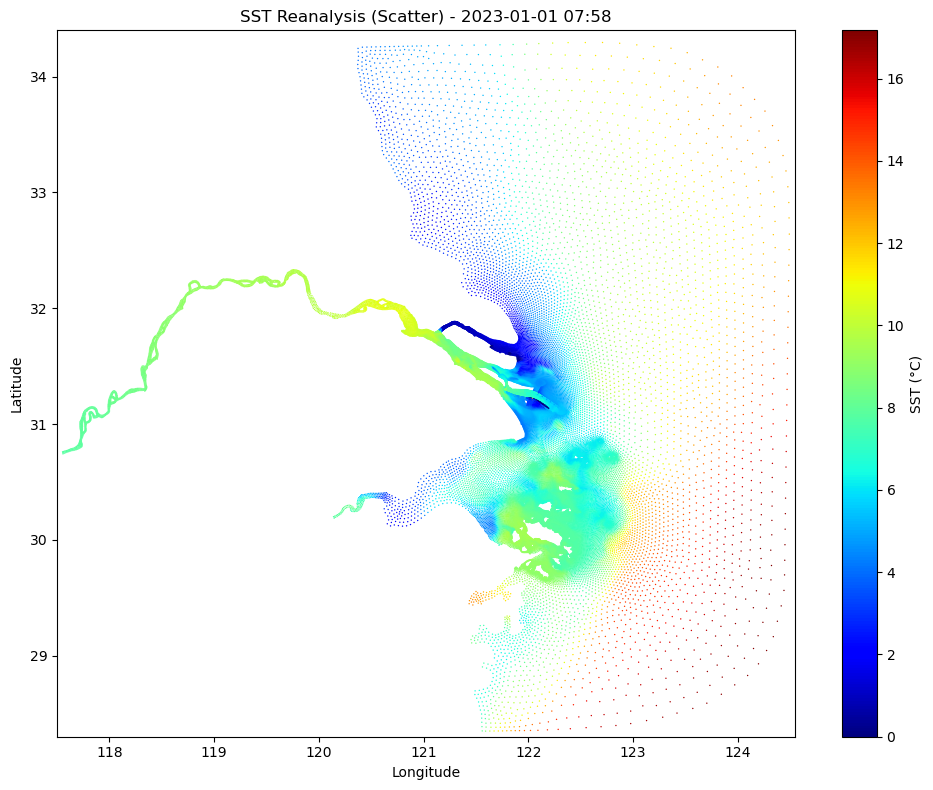

In [5]:
plt.figure(figsize=(10, 8))

plt.scatter(
    lon,
    lat,
    c=sst,
    s=1,
    cmap='jet',
    edgecolor='none'
)

lon_min, lon_max = 117.50, 124.55
lat_min, lat_max = 28.30, 34.40
plt.xlim(lon_min, lon_max)
plt.ylim(lat_min, lat_max)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(label='SST (°C)')
plt.title(f"SST Reanalysis (Scatter) - {time_str}")
plt.tight_layout()
plt.show()

ds.close()

# 精度检查

In [6]:
# 加载网格
lons = np.load('longitude.npy')
lats = np.load('latitude.npy')

# 简单的差分计算分辨率
if lons.ndim == 1:
    res_lon = np.mean(np.diff(lons))
    res_lat = np.mean(np.diff(lats))
else:
    # 如果是二维矩阵，取中心的一行/一列来估算
    mid_row = lons.shape[0] // 2
    res_lon = np.mean(np.diff(lons[mid_row, :]))
    res_lat = np.mean(np.diff(lats[:, mid_row])) # 注意纬度通常沿列变化

print(f"Mask网格分辨率约为: {res_lon:.4f} 度")
# 对于中纬度地区，0.01度大约是1公里
print(f"约等于: {res_lon * 111:.2f} 公里 (纬度方向)")

Mask网格分辨率约为: 0.2500 度
约等于: 27.75 公里 (纬度方向)


In [7]:
def suggest_resolution(nc_file_path, sample_size=5000):
    """
    随机采样 FVCOM 节点，计算平均最近邻距离，从而建议插值分辨率。
    """
    with Dataset(nc_file_path, 'r') as ds:
        lons = ds.variables['lon'][:]
        lats = ds.variables['lat'][:]
    
    n_points = len(lons)
    print(f"FVCOM 数据总节点数: {n_points}")
    
    # 随机采样一部分点来加速计算 (计算所有点的距离太慢了)
    if n_points > sample_size:
        indices = np.random.choice(n_points, sample_size, replace=False)
        sample_lon = lons[indices]
        sample_lat = lats[indices]
    else:
        sample_lon, sample_lat = lons, lats
        
    # 组合成 (lon, lat) 坐标
    points = np.column_stack((sample_lon, sample_lat))
    
    # 使用 KDTree 寻找每个点的最近邻
    tree = cKDTree(points)
    # k=2 因为最近邻是它自己(距离0)，我们要找第2近的点
    dists, _ = tree.query(points, k=2) 
    
    # 取第2列（最近邻距离）
    nearest_dists = dists[:, 1]
    
    avg_dist = np.mean(nearest_dists)
    median_dist = np.median(nearest_dists)
    min_dist = np.min(nearest_dists)
    
    print(f"--- FVCOM 原生密度分析 ---")
    print(f"平均节点间距: {avg_dist:.5f} 度")
    print(f"中位数间距:   {median_dist:.5f} 度 (推荐参考这个)")
    print(f"最小节点间距: {min_dist:.5f} 度 (最密区域)")
    
    print(f"\n>>> 建议设置的网格分辨率: {median_dist:.4f} 度 <<<")
    return median_dist

# === 使用示例 ===
# 找一个你的 nc 文件路径
sample_file = glob.glob('../../Getea/sst_forecast/*.nc')[1]
suggested_res = suggest_resolution(sample_file)

FVCOM 数据总节点数: 50472
--- FVCOM 原生密度分析 ---
平均节点间距: 0.01921 度
中位数间距:   0.01011 度 (推荐参考这个)
最小节点间距: 0.00000 度 (最密区域)

>>> 建议设置的网格分辨率: 0.0101 度 <<<


# 插值

In [8]:
# ================= 1. 全局配置 (Configuration) =================

SOURCE_CONFIG = {
    'forecast': {
        'pattern': '../../Getea/sst_forecast/*.nc',   # 输入路径
        'mode': 'stack',                 # 模式: 堆叠 (Run, Step, H, W)
        'fixed_steps': 120               # 强制固定步长 (不足填充，多余截断)
    },
    'reanalysis': {
        'pattern': '../../Getea/sst_reanalysis/*.nc', # 输入路径
        'mode': 'concat',                # 模式: 拼接 (Time, H, W)
        'fixed_steps': None              # 步长不固定，有多少拼多少
    }
}

OUTPUT_DIR = './'     # 输出文件夹

# U-Net 友好的网格尺寸 (32的倍数)
TARGET_H = 608
TARGET_W = 704
LON_RANGE = (117.50, 124.55)
LAT_RANGE = (28.30, 34.40)

# 自适应去扇形参数 (根据实际效果微调)
ADAPTIVE_K = 8       # 局部密度参考邻居数
ADAPTIVE_TOL = 2.0   # 容忍倍数 (越小切得越狠)

# 全局变量 (仅供子进程使用，无需修改)
worker_triang = None 

# ================= 2. 辅助工具函数 =================

def extract_date_key(filename):
    """
    从文件名中提取第一个数字串作为排序依据。
    解决 'day_1.nc' 排在 'day_10.nc' 之后的问题。
    例如: 'sst_20230101.nc' -> 20230101
    """
    basename = os.path.basename(filename)
    # 寻找连续的数字
    match = re.search(r'\d+', basename)
    if match:
        return int(match.group())
    return 0

def init_worker(x, y, triangles, mask):
    """子进程初始化：重建三角网对象"""
    global worker_triang
    worker_triang = mtri.Triangulation(x, y, triangles=triangles)
    if mask is not None:
        worker_triang.set_mask(mask)

def create_adaptive_triangulation(nc_file):
    """构建智能拓扑 (只在主进程跑一次)"""
    print(f"正在构建自适应拓扑 (Reference: {os.path.basename(nc_file)})...")
    try:
        with Dataset(nc_file, 'r') as ds:
            x = ds.variables['lon'][:]
            y = ds.variables['lat'][:]
        
        # 1. 计算局部密度 (KD-Tree)
        points = np.column_stack([x, y])
        tree = cKDTree(points)
        dists, _ = tree.query(points, k=ADAPTIVE_K + 1)
        local_scale = np.mean(dists[:, 1:], axis=1)
        
        # 2. 构建基础三角网
        triang = mtri.Triangulation(x, y)
        triangles = triang.triangles
        
        # 3. 智能修剪 (Masking)
        scale_tri = local_scale[triangles]
        ref_scale = np.mean(scale_tri, axis=1)
        
        xt, yt = x[triangles], y[triangles]
        # 计算三边长
        edge0 = np.hypot(xt[:,0]-xt[:,1], yt[:,0]-yt[:,1])
        edge1 = np.hypot(xt[:,1]-xt[:,2], yt[:,1]-yt[:,2])
        edge2 = np.hypot(xt[:,2]-xt[:,0], yt[:,2]-yt[:,0])
        max_edge = np.max(np.vstack([edge0, edge1, edge2]), axis=0)
        
        # 如果边长 > 局部尺度 * 容忍因子，则切断
        mask = max_edge > (ref_scale * ADAPTIVE_TOL)
        triang.set_mask(mask)
        
        print(f"拓扑构建完毕: 剔除 {np.sum(mask)} 个非法三角形 (去扇形)")
        return triang
    except Exception as e:
        print(f"拓扑构建失败: {e}")
        raise

def process_file_return_data(args):
    """
    [并行任务] 只负责计算，返回 (SST矩阵, 时间对象列表)
    """
    nc_file, mesh_lon, mesh_lat = args
    global worker_triang
    
    if worker_triang is None: return None

    try:
        with Dataset(nc_file, 'r') as ds:
            # 1. 自动识别 SST 变量名
            target_var = None
            for v in ['sst', 'temp', 'temperature', 'sea_surface_temperature']:
                if v in ds.variables:
                    target_var = v
                    break
            if not target_var: return None

            # 2. 读取 SST 并降维
            data_raw = ds.variables[target_var][:]
            if data_raw.ndim == 3: data_raw = data_raw[:, 0, :] # (Time, Siglay, Node) -> (Time, Node)
            
            # 3. 读取时间 (转为 python datetime)
            if 'time' in ds.variables:
                tvar = ds.variables['time']
                raw_time = tvar[:]
                if np.ma.is_masked(raw_time): raw_time = raw_time.data
                try:
                    time_objs = num2date(raw_time, units=tvar.units)
                except:
                    # 容错: 如果时间解析挂了，生成 dummy 时间
                    time_objs = [datetime.datetime(2000,1,1)] * data_raw.shape[0]
            else:
                time_objs = [datetime.datetime(2000,1,1)] * data_raw.shape[0]

            # 4. 执行空间插值
            time_steps = data_raw.shape[0]
            result_block = np.zeros((time_steps, TARGET_H, TARGET_W), dtype=np.float32)

            for t in range(time_steps):
                interp = mtri.LinearTriInterpolator(worker_triang, data_raw[t])
                # 填充 NaN
                result_block[t] = interp(mesh_lon, mesh_lat).filled(np.nan)
            
            return result_block, time_objs
            
    except Exception as e:
        print(f"Error processing {os.path.basename(nc_file)}: {e}")
        return None

In [9]:
# ================= 3. NetCDF 初始化策略 =================

def init_nc_stack_mode(filename, lat, lon, mask, fixed_steps):
    """[预报模式] 初始化: (run, step, lat, lon)"""
    nc = Dataset(filename, 'w', format='NETCDF4')
    nc.createDimension('run', None)       # 无限维度: 第几次预报
    nc.createDimension('step', fixed_steps) # 固定维度: 预报时长 (120)
    nc.createDimension('lat', lat.shape[0])
    nc.createDimension('lon', lon.shape[1])
    
    # 静态变量
    nc.createVariable('lat', 'f4', ('lat',))[:] = lat[:, 0]
    nc.createVariable('lon', 'f4', ('lon',))[:] = lon[0, :]
    nc.createVariable('land_mask', 'i1', ('lat', 'lon'), zlib=True)[:] = mask
    
    # SST 变量 (4D)
    v = nc.createVariable('sst', 'f4', ('run', 'step', 'lat', 'lon'), 
                          zlib=True, fill_value=np.nan)
    v.description = "SST Forecast (Stacked by Run)"
    
    # 时间变量
    # start_time: 每次 run 的起报时间
    v_start = nc.createVariable('start_time', 'f8', ('run',))
    v_start.units = 'hours since 2023-01-01 00:00:00'
    
    # valid_time: 每个 step 对应的真实时间
    v_valid = nc.createVariable('valid_time', 'f8', ('run', 'step'))
    v_valid.units = 'hours since 2023-01-01 00:00:00'
    
    return nc

def init_nc_concat_mode(filename, lat, lon, mask):
    """[再分析模式] 初始化: (time, lat, lon)"""
    nc = Dataset(filename, 'w', format='NETCDF4')
    nc.createDimension('time', None)
    nc.createDimension('lat', lat.shape[0])
    nc.createDimension('lon', lon.shape[1])
    
    nc.createVariable('lat', 'f4', ('lat',))[:] = lat[:, 0]
    nc.createVariable('lon', 'f4', ('lon',))[:] = lon[0, :]
    nc.createVariable('land_mask', 'i1', ('lat', 'lon'), zlib=True)[:] = mask
    
    nc.createVariable('sst', 'f4', ('time', 'lat', 'lon'), zlib=True, fill_value=np.nan)
    t = nc.createVariable('time', 'f8', ('time',))
    t.units = 'hours since 2023-01-01 00:00:00'
    
    return nc

In [10]:
# ================= 4. 主流程 =================

def main():
    if os.path.exists(OUTPUT_DIR) and os.path.abspath(OUTPUT_DIR) != os.path.abspath('.'):
        shutil.rmtree(OUTPUT_DIR)
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    # 1. 准备目标网格
    grid_lon = np.linspace(LON_RANGE[0], LON_RANGE[1], TARGET_W)
    grid_lat = np.linspace(LAT_RANGE[0], LAT_RANGE[1], TARGET_H)
    mesh_lon, mesh_lat = np.meshgrid(grid_lon, grid_lat)
    
    for source_name, config in SOURCE_CONFIG.items():
        # 搜索文件
        files = glob.glob(config['pattern'])

        # 排除文件名中包含 'stationsout' 的文件
        files = [f for f in files if 'stationsout' not in os.path.basename(f)]
        
        # --- 关键步骤: 智能排序 ---
        # 确保按文件名里的日期/数字排序，防止时间乱序
        files = sorted(files, key=extract_date_key)
        
        if not files:
            print(f"Skipping {source_name}: No files found.")
            continue
        
        print(f"\n=== 开始处理: {source_name} (模式: {config['mode']}, 文件数: {len(files)}) ===")
        
        # 2. 建立拓扑 (假设同一来源网格一致)
        # 如果文件损坏，尝试找下一个
        triang = None
        for f in files:
            try:
                triang = create_adaptive_triangulation(f)
                break
            except: continue
        
        if triang is None:
            print("错误: 无法构建网格拓扑，退出。")
            continue
            
        # 生成 Mask
        mask_interp = mtri.LinearTriInterpolator(triang, np.ones(triang.x.shape))
        valid_mask = mask_interp(mesh_lon, mesh_lat).filled(0.0).astype(np.int8)
        
        # 3. 初始化 NC 文件
        out_path = os.path.join(OUTPUT_DIR, f"{source_name}_structured.nc")
        if config['mode'] == 'stack':
            nc = init_nc_stack_mode(out_path, mesh_lat, mesh_lon, valid_mask, config['fixed_steps'])
        else:
            nc = init_nc_concat_mode(out_path, mesh_lat, mesh_lon, valid_mask)
            
        # 4. 并行计算 -> 串行写入
        tasks = [(f, mesh_lon, mesh_lat) for f in files]
        init_args = (triang.x, triang.y, triang.triangles, triang.mask)
        
        curr_idx = 0
        
        print("启动并行处理...")
        with ProcessPoolExecutor(initializer=init_worker, initargs=init_args) as executor:
            # 使用 map 严格保证结果顺序与 files 排序一致
            for result in tqdm(executor.map(process_file_return_data, tasks), total=len(files)):
                if result is None: continue
                
                block_data, block_times = result
                
                # === 分支 A: 堆叠模式 (Forecast) ===
                if config['mode'] == 'stack':
                    # 检查步长，如果不足则填充，如果多了则截断
                    target_steps = config['fixed_steps']
                    actual_steps = block_data.shape[0]
                    
                    final_data = np.full((target_steps, TARGET_H, TARGET_W), np.nan)
                    final_times = [block_times[0]] * target_steps # 初始化占位
                    
                    use_len = min(actual_steps, target_steps)
                    
                    # 复制数据
                    final_data[:use_len] = block_data[:use_len]
                    final_times[:use_len] = block_times[:use_len]
                    
                    # 写入 NetCDF (run, step, lat, lon)
                    nc.variables['sst'][curr_idx, :, :, :] = final_data
                    
                    # 写入时间
                    t_unit = nc.variables['start_time'].units
                    # 起报时间 (第0个时刻)
                    nc.variables['start_time'][curr_idx] = date2num(final_times[0], units=t_unit)
                    # 全过程时间
                    nc.variables['valid_time'][curr_idx, :] = date2num(final_times, units=t_unit)
                    
                    curr_idx += 1 # Run ID 增加
                
                # === 分支 B: 拼接模式 (Reanalysis) ===
                else:
                    n = block_data.shape[0]
                    # 直接追加
                    nc.variables['sst'][curr_idx : curr_idx+n] = block_data
                    
                    t_nums = date2num(block_times, units=nc.variables['time'].units)
                    nc.variables['time'][curr_idx : curr_idx+n] = t_nums
                    
                    curr_idx += n
        
        nc.close()
        print(f"✅ 处理完成! 结果已保存至: {out_path}")

if __name__ == '__main__':
    main()


=== 开始处理: forecast (模式: stack, 文件数: 360) ===
正在构建自适应拓扑 (Reference: sst_changjiang_2023010108.nc)...
拓扑构建完毕: 剔除 3195 个非法三角形 (去扇形)
启动并行处理...


100%|██████████| 360/360 [16:24<00:00,  2.73s/it] 


✅ 处理完成! 结果已保存至: ./forecast_structured.nc

=== 开始处理: reanalysis (模式: concat, 文件数: 369) ===
正在构建自适应拓扑 (Reference: sst_Re_2023010108.nc)...
拓扑构建完毕: 剔除 3195 个非法三角形 (去扇形)
启动并行处理...


100%|██████████| 369/369 [02:40<00:00,  2.30it/s]


✅ 处理完成! 结果已保存至: ./reanalysis_structured.nc


# 绘图展示

In [11]:
# ================= 配置 =================
# 你可以换成 'reanalysis_structured.nc' 来测试另一种模式
FILE_PATH = './forecast_structured.nc' 

def get_sst_and_time(ds, run_idx=0, step_idx=0):
    """
    核心工具：自动判断 3D/4D 结构并提取数据
    """
    # 1. 读取变量
    sst_var = ds.variables['sst']
    
    # 2. 判断维度
    # ndim == 4 -> Forecast (run, step, lat, lon)
    # ndim == 3 -> Reanalysis (time, lat, lon)
    if sst_var.ndim == 4:
        mode = 'forecast (4D)'
        # 提取指定 Run 的指定 Step
        # 注意边界检查
        max_run = sst_var.shape[0]
        max_step = sst_var.shape[1]
        if run_idx >= max_run or step_idx >= max_step:
            raise ValueError(f"索引越界! Max Run={max_run}, Max Step={max_step}")
            
        data = sst_var[run_idx, step_idx, :, :]
        
        # 提取对应的时间 (valid_time 是 2D: run x step)
        t_var = ds.variables['valid_time']
        t_num = t_var[run_idx, step_idx]
        t_obj = num2date(t_num, units=t_var.units)
        
    else:
        mode = 'reanalysis (3D)'
        # Reanalysis 只有时间维，这里复用 step_idx 作为 time_idx
        # run_idx 在这里无意义
        max_time = sst_var.shape[0]
        if step_idx >= max_time:
            raise ValueError(f"时间索引越界! Max Time={max_time}")
            
        data = sst_var[step_idx, :, :]
        
        # 提取时间
        t_var = ds.variables['time']
        t_num = t_var[step_idx]
        t_obj = num2date(t_num, units=t_var.units)
    
    # 标准化时间对象 (处理 cftime)
    if not isinstance(t_obj, datetime.datetime):
        t_str = f"{t_obj.year}-{t_obj.month:02d}-{t_obj.day:02d} {t_obj.hour:02d}:{t_obj.minute:02d}"
    else:
        t_str = t_obj.strftime('%Y-%m-%d %H:%M')
        
    return data, t_str, mode

def plot_spatial_map(nc_file, run_idx=0, step_idx=0):
    """
    画空间分布图 (支持 Forecast 和 Reanalysis)
    run_idx: 第几次预报 (仅对 Forecast 有效)
    step_idx: 第几个小时 (或 Reanalysis 的第几个时刻)
    """
    if not os.path.exists(nc_file):
        print(f"文件不存在: {nc_file}")
        return

    with Dataset(nc_file, 'r') as ds:
        lat = ds.variables['lat'][:]
        lon = ds.variables['lon'][:]
        mask = ds.variables['land_mask'][:]
        
        # 调用核心工具获取数据
        try:
            sst, time_str, mode = get_sst_and_time(ds, run_idx, step_idx)
            print(f"读取模式: {mode} | 时间: {time_str}")
        except Exception as e:
            print(f"读取失败: {e}")
            return

    # 绘图
    plt.figure(figsize=(10, 8))
    # 动态 Colorbar
    mesh = plt.pcolormesh(lon, lat, sst, cmap='jet', shading='auto')
    plt.colorbar(mesh, label='SST (°C)')
    
    # 叠加 Mask 轮廓
    plt.contour(lon, lat, mask, levels=[0.5], colors='k', linewidths=0.8)
    
    plt.title(f"SST Map [{mode}]\nTime: {time_str} (Run={run_idx}, Step={step_idx})", fontsize=14)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

def plot_time_series(nc_file, lon_target, lat_target, run_idx=0):
    """
    画时间序列图
    对于 Forecast: 画指定 run_idx 的 120 小时变化
    对于 Reanalysis: 画整段时间轴的变化 (忽略 run_idx)
    """
    with Dataset(nc_file, 'r') as ds:
        # 1. 找网格点
        lat_vec = ds.variables['lat'][:]
        lon_vec = ds.variables['lon'][:]
        iy = np.abs(lat_vec - lat_target).argmin()
        ix = np.abs(lon_vec - lon_target).argmin()
        print(f"Target: ({lon_target}, {lat_target}) -> Grid: ({lon_vec[ix]:.2f}, {lat_vec[iy]:.2f})")
        
        sst_var = ds.variables['sst']
        
        # 2. 根据维度提取序列
        if sst_var.ndim == 4:
            # Forecast: 取第 run_idx 次预报的所有 step
            # Shape: (120,)
            sst_series = sst_var[run_idx, :, iy, ix]
            
            # 时间: valid_time [run_idx, :]
            t_var = ds.variables['valid_time']
            raw_times = t_var[run_idx, :]
            t_unit = t_var.units
            label_prefix = f"Forecast Run {run_idx}"
        else:
            # Reanalysis: 取所有时间
            sst_series = sst_var[:, iy, ix]
            
            t_var = ds.variables['time']
            raw_times = t_var[:]
            t_unit = t_var.units
            label_prefix = "Reanalysis"

        # 3. 处理时间
        if np.ma.is_masked(raw_times): raw_times = raw_times.data
        times = num2date(raw_times, units=t_unit)
        
        # cftime 转 datetime
        if len(times) > 0 and not isinstance(times[0], datetime.datetime):
            times = [datetime.datetime(t.year, t.month, t.day, t.hour, t.minute) for t in times]
            
    # 绘图
    plt.figure(figsize=(12, 5))
    if np.isnan(sst_series).all():
         plt.text(0.5, 0.5, "Land (NaN)", ha='center', transform=plt.gca().transAxes)
    else:
        plt.plot(times, sst_series, '.-', label=label_prefix)
        
    plt.title(f"SST Time Series @ ({lon_vec[ix]:.2f}E, {lat_vec[iy]:.2f}N)")
    plt.ylabel("SST (°C)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.gcf().autofmt_xdate()
    plt.tight_layout()
    plt.show()

读取模式: forecast (4D) | 时间: 2023-01-01 18:00


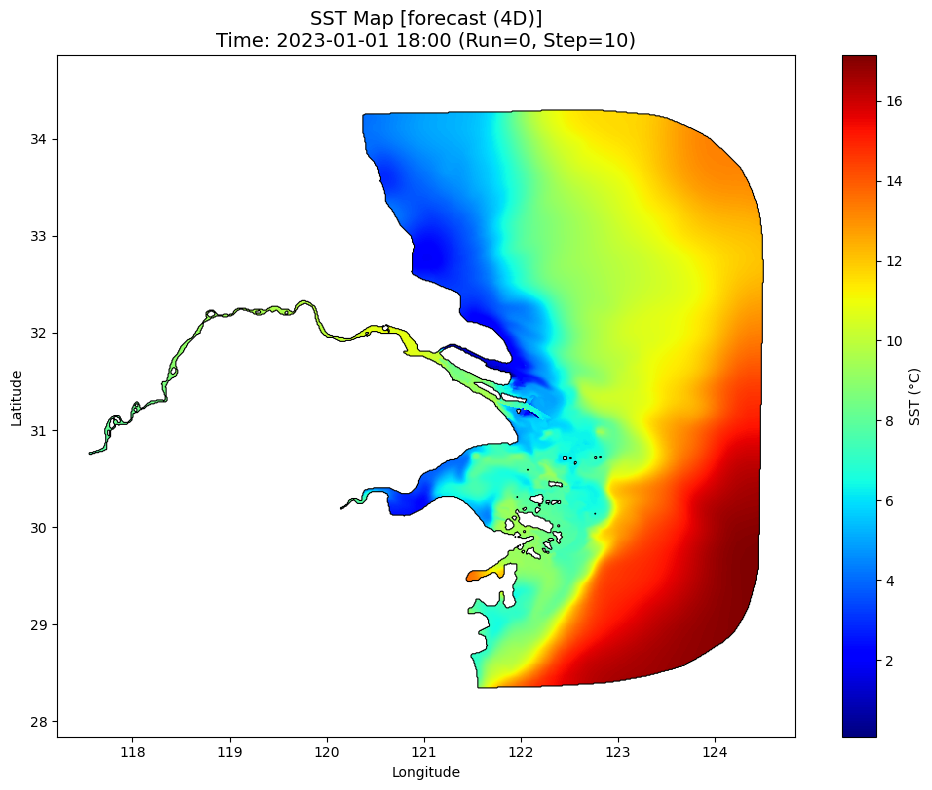

Target: (123.0, 31.5) -> Grid: (123.00, 31.50)


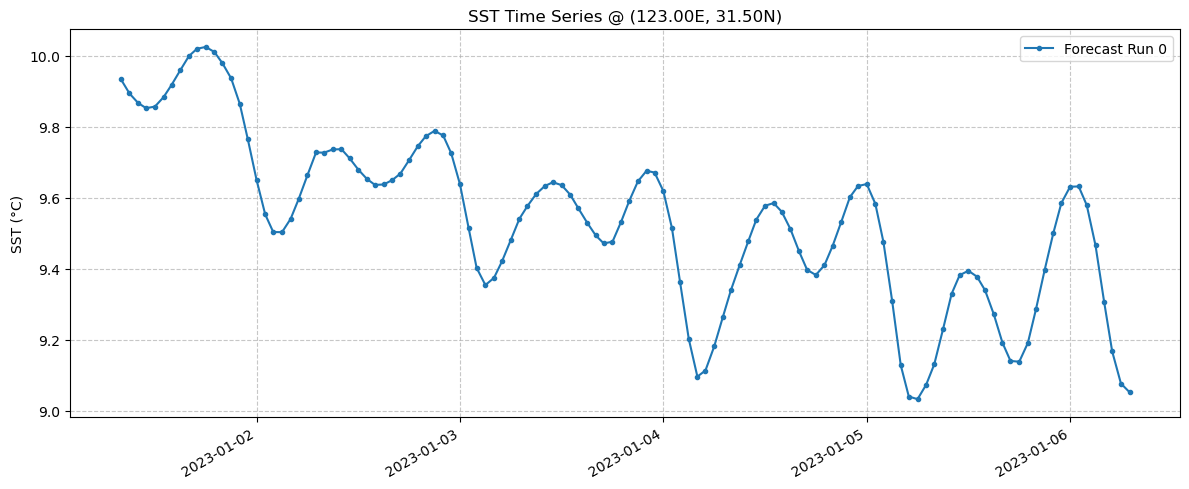

In [12]:
# ================= 测试 =================
if __name__ == "__main__":
    # 1. 测试空间图
    # 如果是 Forecast: 画第 0 个批次的第 10 个小时
    # 如果是 Reanalysis: 画第 10 个时刻
    plot_spatial_map(FILE_PATH, run_idx=0, step_idx=10)
    
    # 2. 测试时间序列
    # 如果是 Forecast: 画第 0 个批次的完整 120 小时
    plot_time_series(FILE_PATH, lon_target=123.0, lat_target=31.5, run_idx=0)